<a href="https://colab.research.google.com/github/adhithya2525/adhi-15day-workshop/blob/main/Day3/Day3_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
API_KEY='91c4518282ff171a3ca0a0b8fe52a8a2'
BASE_URL='https://api.openweathermap.org/data/2.5/weather'
CITIES=['Mumbai','Delhi','Coimbatore','Chennai','Madurai','Pune','Salem']

In [ ]:
def fetch_weather(city,api_key):
    params={
        'q':city,
        'appid':api_key,
        'units':'metric'
    }
    response=requests.get(BASE_URL,params=params)
    return response.json()

In [ ]:
import requests

In [ ]:
weather_data = {}
for city in CITIES:
    data = fetch_weather(city, API_KEY)
    weather_data[city] = data

for city, data in weather_data.items():
    print(f"Weather in {city}: {data.get('weather')[0].get('description')}, Temperature: {data.get('main').get('temp')}°C")

Weather in Mumbai: haze, Temperature: 33.99°C
Weather in Delhi: clear sky, Temperature: 44.05°C
Weather in Coimbatore: scattered clouds, Temperature: 33.88°C
Weather in Chennai: few clouds, Temperature: 36.11°C
Weather in Madurai: scattered clouds, Temperature: 39.01°C
Weather in Pune: overcast clouds, Temperature: 36.89°C
Weather in Salem: scattered clouds, Temperature: 36.42°C


In [ ]:
import urllib.parse

print("Google Weather Search Links:")
for city in CITIES:
    search_query = f"weather in {city}"
    encoded_query = urllib.parse.quote_plus(search_query)
    google_url = f"https://www.google.com/search?q={encoded_query}"
    print(f"- {city}: {google_url}")

Google Weather Search Links:
- Mumbai: https://www.google.com/search?q=weather+in+Mumbai
- Delhi: https://www.google.com/search?q=weather+in+Delhi
- Coimbatore: https://www.google.com/search?q=weather+in+Coimbatore
- Chennai: https://www.google.com/search?q=weather+in+Chennai
- Madurai: https://www.google.com/search?q=weather+in+Madurai
- Pune: https://www.google.com/search?q=weather+in+Pune
- Salem: https://www.google.com/search?q=weather+in+Salem


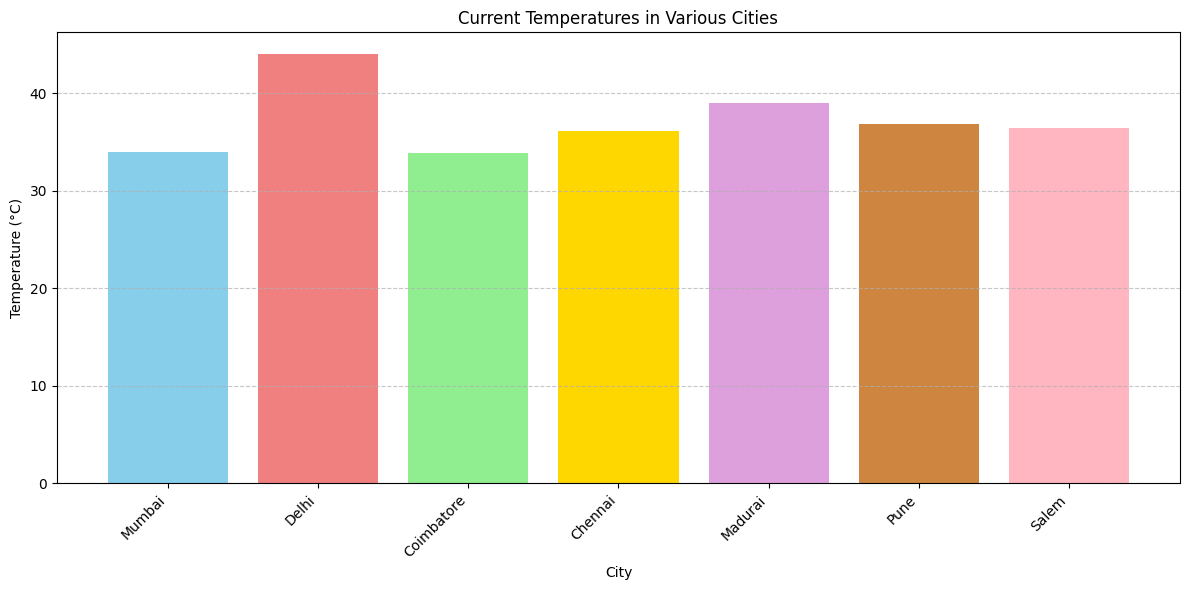

In [ ]:
import matplotlib.pyplot as plt
cities = [city for city in weather_data.keys()]
temperatures = [data.get('main', {}).get('temp') for data in weather_data.values()]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'peru', 'lightpink']
plt.figure(figsize=(12, 6))
plt.bar(cities, temperatures, color=colors[:len(cities)])
plt.xlabel('City')
plt.ylabel('Temperature (°C)')
plt.title('Current Temperatures in Various Cities')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
def fetch_weather(city,api_key):
    params={
        'q':city,
        'appid':api_key,
        'units':'metric'
    }
    response=requests.get(BASE_URL,params=params)
    return response.json()

In [ ]:
import pandas as pd # Import pandas for DataFrame creation
import matplotlib.pyplot as plt # Import matplotlib for plotting

weather_data_flattened = []

# Iterate directly over the values of the weather_data dictionary
# Each 'city_raw_data' will be one of the dictionaries stored under a city name (e.g., weather_data['Mumbai'])
for city_raw_data in weather_data.values():
    city_data = {
        'city_name': city_raw_data['name'],
        'latitude': city_raw_data['coord']['lat'],
        'longitude': city_raw_data['coord']['lon'],
        'temperature_celsius': city_raw_data['main']['temp'],
        'feels_like_celsius': city_raw_data['main']['feels_like'],
        'humidity_percent': city_raw_data['main']['humidity'],
        'pressure_hPa': city_raw_data['main']['pressure'],
        'weather_description': city_raw_data['weather'][0]['description']
    }
    weather_data_flattened.append(city_data)

df_weather_flat = pd.DataFrame(weather_data_flattened)
display(df_weather_flat.head(10))

# Create a bar plot comparing actual temperature and feels like temperature
plt.figure(figsize=(14, 7))

bar_width = 0.35
index = range(len(df_weather_flat['city_name']))

plt.bar(index, df_weather_flat['temperature_celsius'], bar_width, label='Temperature (°C)', color='skyblue')
plt.bar([i + bar_width for i in index], df_weather_flat['feels_like_celsius'], bar_width, label='Feels Like (°C)', color='lightcoral')

plt.xlabel('City')
plt.ylabel('Temperature (°C)')
plt.title('Actual vs. Feels Like Temperature in Various Cities')
plt.xticks([i + bar_width / 2 for i in index], df_weather_flat['city_name'], rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

,city_name,latitude,longitude,temperature_celsius,feels_like_celsius,humidity_percent,pressure_hPa,weather_description
0,Mumbai,19.0144,72.8479,33.99,40.16,55,1009,haze
1,Delhi,28.6667,77.2167,44.05,41.11,10,999,clear sky
2,Coimbatore,11.0000,76.9667,33.88,38.81,52,1008,scattered clouds
3,Chennai,13.0878,80.2785,36.11,43.11,52,1005,few clouds
4,Madurai,9.9333,78.1167,39.01,46.01,42,1006,scattered clouds
5,Pune,18.5196,73.8553,36.89,37.02,28,1008,overcast clouds
6,Salem,11.6500,78.1667,36.42,43.42,54,1008,scattered clouds
